# Accelerate Attention — Benchmark on NVIDIA L4

Compares three attention implementations exposed by `modules/attention.py`:

- `baseline` — original hand-written QKᵀ → softmax → V (no kernel fusion)
- `flash`    — PyTorch SDPA, which dispatches to the **FlashAttention-2** kernel on L4 (sm_89) with bf16/fp16
- `swa`      — Sliding Window Attention (Longformer-style). Uses `flash-attn`'s native `window_size` if the library is installed, otherwise falls back to a banded mask via SDPA (correct utility tradeoff, no compute speedup)

**Run on Google Colab with a single L4 GPU.**

Outputs:
1. Correctness check — baseline ≈ flash; SWA with full window ≈ baseline; SWA with small window diverges.
2. Speed sweep — forward / forward+backward latency vs seq_len ∈ {128, 256, 512, 1024, 2048, 4096}.
3. Speedup table and curves vs baseline.
4. Profiler kernel breakdown for one configuration.

## 1. Clone repository and switch to the `feat/AcceleAtt` branch

In [59]:
import os, subprocess

REPO_URL = 'https://github.com/Lynx-Zhang/DD2424-Project.git'
REPO_DIR = '/content/DD2424-Project'
BRANCH   = 'feat/AcceleAtt'

if not os.path.isdir(REPO_DIR):
    subprocess.run(['git', 'clone', '-b', BRANCH, REPO_URL, REPO_DIR], check=True)
    
else:
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'checkout', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'pull', 'origin', BRANCH], check=True)

os.chdir(REPO_DIR)
print('cwd:', os.getcwd())
subprocess.run(['git', 'log', '-1', '--oneline'])

cwd: /content/DD2424-Project


CompletedProcess(args=['git', 'log', '-1', '--oneline'], returncode=0)

## 2. Install dependencies

`einops` is required by the model code. `flash-attn` is optional — if the install succeeds, SWA will use the native `window_size` argument (true O(N·w) compute); if it fails, SWA falls back to a banded mask via SDPA. The notebook works either way.

In [6]:
!grep -n "torch.compile" /content/DD2424-Project/modules/attention.py
!echo "---"
!head -15 /content/DD2424-Project/modules/attention.py

11:  flex_attention = torch.compile(_flex_attention_eager, dynamic=False)
---
import torch
import torch.nn.functional as F

from einops import rearrange
from torch import nn

try:
  from torch.nn.attention.flex_attention import flex_attention as _flex_attention_eager, create_block_mask
  # Compile for true block-sparse O(N*w). Without compile FlexAttention
  # materializes the full N*N score matrix (~no speedup vs baseline).
  flex_attention = torch.compile(_flex_attention_eager, dynamic=False)
  _HAS_FLEX_ATTENTION = True
except ImportError:
  _HAS_FLEX_ATTENTION = False



In [7]:
import os
os.chdir('/content/DD2424-Project')
import modules.attention as m

print('flex_attention type:', type(m.flex_attention).__name__)
print('flex_attention repr:', repr(m.flex_attention)[:120])

# 看看是不是真的 compile 过
print()
print('has _torchdynamo_orig_callable?', hasattr(m.flex_attention, '_torchdynamo_orig_callable'))

flex_attention type: function
flex_attention repr: <function flex_attention at 0x7d8339a82d40>

has _torchdynamo_orig_callable? True


In [8]:
import torch, time
import torch._dynamo
torch._dynamo.config.suppress_errors = False  # 让编译错误炸出来

from torch.nn.attention.flex_attention import flex_attention as fa_eager, create_block_mask
fa_compiled = torch.compile(fa_eager, dynamic=False)

def mask(b, h, q, kv): return q >= kv
bm = create_block_mask(mask, B=None, H=None, Q_LEN=512, KV_LEN=512, device='cuda')

q = torch.randn(2, 12, 512, 64, device='cuda', dtype=torch.bfloat16)
k = torch.randn_like(q); v = torch.randn_like(q)

# 1) 先试 compiled，看是否报错
print('--- compiled call ---')
try:
    out = fa_compiled(q, k, v, block_mask=bm)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(20):
        out = fa_compiled(q, k, v, block_mask=bm)
    torch.cuda.synchronize()
    print(f'compiled OK: {(time.perf_counter()-t0)*1000/20:.3f} ms/call')
except Exception as e:
    print(f'COMPILE FAILED: {type(e).__name__}: {e}')

# 2) 对比 eager
print('--- eager call ---')
torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(20):
    out = fa_eager(q, k, v, block_mask=bm)
torch.cuda.synchronize()
print(f'eager: {(time.perf_counter()-t0)*1000/20:.3f} ms/call')

--- compiled call ---
compiled OK: 0.122 ms/call
--- eager call ---


/usr/local/lib/python3.12/dist-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SOLUTION: Use torch.compile(flex_attention)(...)

If you want to debug your score_mod/mask_mod, you can set:
torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True

This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
  _warn_once(


eager: 60.056 ms/call


In [ ]:
!pip install -q \
    einops==0.8.0 \
    transformers==4.46.3 \
    tokenizers==0.20 \
    sacrebleu==2.5.1 \
    scikit-learn \
    matplotlib

# !pip install -q datasets

# Optional: flash-attn enables true O(N*w) compute for SWA. If install fails,
# SWA automatically falls back to a banded mask via SDPA.
# !pip install -q flash-attn --no-build-isolation || echo '[WARN] flash-attn install failed; SWA will use dense-mask fallback.'

print("Dependencies installed.")

Dependencies installed.


test flex_atttention 

In [4]:
import inspect, modules.attention as m
src = inspect.getsource(m)
print('torch.compile in attention.py?', 'torch.compile(_flex_attention_eager' in src)
print()
print(src.split('\n')[6:14])  # 前几行 import 区

ModuleNotFoundError: No module named 'modules'

verify the version of pytorch

In [3]:
import torch
print('torch:', torch.__version__)
try:
    from torch.nn.attention.flex_attention import flex_attention
    print('✓ FlexAttention available — recommend using this for SWA')
except ImportError:
    print('✗ FlexAttention not available — torch too old')

torch: 2.10.0+cu128
✓ FlexAttention available — recommend using this for SWA


## 3. GPU sanity check

In [10]:
import torch
print('torch                :', torch.__version__)
print('CUDA available       :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device               :', torch.cuda.get_device_name(0))
    print('compute capability   :', torch.cuda.get_device_capability(0))
    print('bf16 supported       :', torch.cuda.is_bf16_supported())

# SWA acceleration backend detection (in priority order).
# attention.py prefers FlexAttention → flash-attn → dense-mask in that order.
try:
    from torch.nn.attention.flex_attention import flex_attention
    print('SWA backend          : FlexAttention (torch native, true O(N*w))')
    SWA_BACKEND = 'flex_attention'
except ImportError:
    try:
        import flash_attn
        print(f'SWA backend          : flash-attn {flash_attn.__version__} (true O(N*w))')
        SWA_BACKEND = 'flash_attn'
    except ImportError:
        print('SWA backend          : dense-mask fallback (no speedup — install flash-attn or upgrade torch)')
        SWA_BACKEND = 'dense_mask'


torch                : 2.10.0+cu128
CUDA available       : True
device               : NVIDIA L4
compute capability   : (8, 9)
bf16 supported       : True
SWA backend          : FlexAttention (torch native, true O(N*w))


## 4. Correctness check

All three modes are built with the **same weights**; we verify:
- `flash` numerical diff vs `baseline` is small (different kernel, same math, expect small fp error).
- `swa` with a window ≥ seq_len should also match `baseline` (the band covers the whole sequence).
- `swa` with a small window deviates — confirms the mask is doing something.

In [9]:
import torch
from config import GPT2Config
from modules.attention import CausalSelfAttention

device = 'cuda'
torch.manual_seed(0)

cfg = GPT2Config()
baseline = CausalSelfAttention(cfg).to(device).eval()

def clone_layer(impl, swa_w=128):
    c = GPT2Config(attn_impl=impl, swa_window_size=swa_w)
    layer = CausalSelfAttention(c).to(device).eval()
    layer.load_state_dict(baseline.state_dict())
    return layer

flash      = clone_layer('flash')
swa_wide   = clone_layer('swa', swa_w=1024)   # window >= seq_len → ~full attention
swa_small  = clone_layer('swa', swa_w=8)

B, N = 2, 64
x = torch.randn(B, N, cfg.hidden_size, device=device)
mask = torch.zeros(B, 1, 1, N, device=device)

with torch.no_grad():
    o_base  = baseline(x, mask)
    o_flash = flash(x, mask)
    o_wide  = swa_wide(x, mask)
    o_small = swa_small(x, mask)

print(f'flash      vs baseline: max abs diff = {(o_base - o_flash ).abs().max().item():.3e}  (expect ~1e-5)')
print(f'swa(w=1024) vs baseline: max abs diff = {(o_base - o_wide  ).abs().max().item():.3e}  (expect ~1e-5)')
print(f'swa(w=8)    vs baseline: max abs diff = {(o_base - o_small ).abs().max().item():.3e}  (expect LARGE — different math)')

flash      vs baseline: max abs diff = 3.576e-07  (expect ~1e-5)
swa(w=1024) vs baseline: max abs diff = 0.000e+00  (expect ~1e-5)
swa(w=8)    vs baseline: max abs diff = 8.288e-01  (expect LARGE — different math)


## 5. Speed micro-benchmark

Measures forward and forward+backward time of a single `CausalSelfAttention` layer (B=8, H=12, D=64 — GPT-2 small head config) in bf16. CUDA events for timing, 10 warmup iters, 30 measurement iters.

In [ ]:
import gc, torch
from config import GPT2Config
from modules.attention import CausalSelfAttention

def bench(impl, seq_len, batch=8, dtype=torch.bfloat16, n_warm=10, n_iter=30, swa_w=128, swa_sink=0):
    cfg = GPT2Config(attn_impl=impl, swa_window_size=swa_w, swa_sink_size=swa_sink)
    layer = CausalSelfAttention(cfg).to('cuda').to(dtype).train()

    x = torch.randn(batch, seq_len, cfg.hidden_size, device='cuda', dtype=dtype, requires_grad=True)
    mask = torch.zeros(batch, 1, 1, seq_len, device='cuda', dtype=dtype)
    g = torch.randn(batch, seq_len, cfg.hidden_size, device='cuda', dtype=dtype)
    torch.cuda.reset_peak_memory_stats() 

    # warmup
    for _ in range(n_warm):
        out = layer(x, mask)
        out.backward(g)
        x.grad = None
        for p in layer.parameters(): p.grad = None
    torch.cuda.synchronize()
    # warm up no record
    for _ in range(5):
        with torch.no_grad():
            _ = layer(x, mask)
    torch.cuda.synchronize()

    starter = torch.cuda.Event(enable_timing=True)
    ender   = torch.cuda.Event(enable_timing=True)

    # forward only
    starter.record()
    for _ in range(n_iter):
        with torch.no_grad():
            out = layer(x, mask)
    ender.record()
    torch.cuda.synchronize()
    fwd_ms = starter.elapsed_time(ender) / n_iter

    # forward + backward
    starter.record()
    for _ in range(n_iter):
        out = layer(x, mask)
        out.backward(g)
        x.grad = None
        for p in layer.parameters(): p.grad = None
    ender.record()
    torch.cuda.synchronize()
    fwd_bwd_ms = starter.elapsed_time(ender) / n_iter

    peak_mem_mb = torch.cuda.max_memory_allocated() / 1024**2

    del layer, x, mask, g
    gc.collect(); torch.cuda.empty_cache()
    return fwd_ms, fwd_bwd_ms, peak_mem_mb

print('bench function ready (supports swa_sink)')

In [37]:
import torch._dynamo
torch._dynamo.config.recompile_limit = 64

In [38]:
import torch, torch._dynamo
import modules.attention as m
from torch.nn.attention.flex_attention import flex_attention as _fa_eager

torch._dynamo.config.recompile_limit = 256
torch._dynamo.reset()  # 清掉之前 dynamic=False 的编译缓存

# Override 成 dynamic=True：一次编译适用所有 N
m.flex_attention = torch.compile(_fa_eager, dynamic=True)

print('flex_attention re-compiled with dynamic=True')
print('recompile_limit =', torch._dynamo.config.recompile_limit)

flex_attention re-compiled with dynamic=True
recompile_limit = 256


In [ ]:
import json

seq_lens = [128, 256, 512, 1024, 2048, 4096]
configs = [
    # (impl,    window, sink, label)
    ('baseline', None,  0,    'baseline'),
    ('flash',    None,  0,    'flash'),
    # SWA without sinks
    ('swa',       64,   0,    'swa-w64'),
    ('swa',      128,   0,    'swa-w128'),
    ('swa',      256,   0,    'swa-w256'),
    # SWA + Attention Sinks (4 sink tokens, StreamingLLM-style)
    ('swa',       64,   4,    'swa-w64+sinks4'),
    ('swa',      128,   4,    'swa-w128+sinks4'),
    ('swa',      256,   4,    'swa-w256+sinks4'),
]

results = {label: [] for _, _, _, label in configs}

for impl, w, sink, label in configs:
    for N in seq_lens:
        try:
            fwd, fb, mem = bench(
                impl, N,
                swa_w=(w if w is not None else 128),
                swa_sink=sink,
            )
            results[label].append({'N': N, 'fwd_ms': fwd, 'fwd_bwd_ms': fb, 'peak_mem_mb': mem})
            print(f'{label:>18s}  N={N:>5d}  fwd={fwd:7.3f} ms  fwd+bwd={fb:7.3f} ms  peak={mem:7.1f} MB')
        except torch.cuda.OutOfMemoryError:
            results[label].append({'N': N, 'fwd_ms': float('nan'), 'fwd_bwd_ms': float('nan'), 'peak_mem_mb': float('nan')})
            print(f'{label:>18s}  N={N:>5d}  OOM')
            torch.cuda.empty_cache()

with open('bench_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print()
print('saved → bench_results.json')

## 6. Plot and speedup table

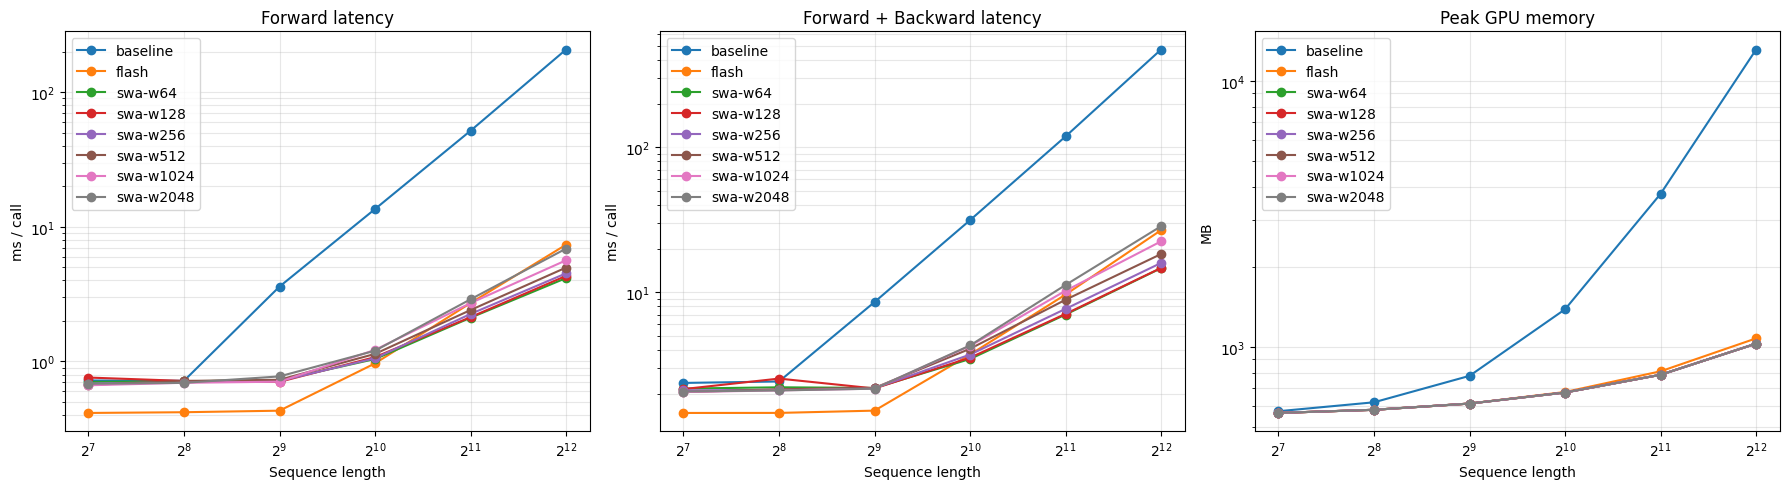

saved → bench_attention.png


In [53]:
import math
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label, rows in results.items():
    Ns   = [r['N']           for r in rows]
    fwds = [r['fwd_ms']      for r in rows]
    fbs  = [r['fwd_bwd_ms']  for r in rows]
    mems = [r['peak_mem_mb'] for r in rows]
    axes[0].plot(Ns, fwds, marker='o', label=label)
    axes[1].plot(Ns, fbs,  marker='o', label=label)
    axes[2].plot(Ns, mems, marker='o', label=label)

for ax, title, ylabel in zip(
    axes,
    ['Forward latency', 'Forward + Backward latency', 'Peak GPU memory'],
    ['ms / call', 'ms / call', 'MB'],
):
    ax.set_xlabel('Sequence length')
    ax.set_ylabel(ylabel)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('bench_attention.png', dpi=140)
plt.show()
print('saved → bench_attention.png')

In [54]:
# Speedup vs baseline (forward + backward)
labels = list(results.keys())
base_by_N = {r['N']: r['fwd_bwd_ms'] for r in results['baseline']}

header = f"{'N':>6s}" + ''.join(f"{l:>14s}" for l in labels)
print(header)
print('-' * len(header))
for N in seq_lens:
    row = f"{N:>6d}"
    for l in labels:
        d = {r['N']: r['fwd_bwd_ms'] for r in results[l]}
        v = d.get(N, float('nan'))
        b = base_by_N.get(N, float('nan'))
        if v != v or b != b:
            row += f"{'N/A':>14s}"
        else:
            row += f"{b / v:>13.2f}x"
    print(row)
print()
print('Values are speedup over baseline (>1 means faster).')

     N      baseline         flash       swa-w64      swa-w128      swa-w256      swa-w512     swa-w1024     swa-w2048
----------------------------------------------------------------------------------------------------------------------
   128         1.00x         1.61x         1.09x         1.10x         1.13x         1.16x         1.16x         1.15x
   256         1.00x         1.65x         1.10x         0.95x         1.14x         1.13x         1.15x         1.15x
   512         1.00x         5.61x         3.91x         3.95x         3.93x         3.91x         3.96x         3.96x
  1024         1.00x         8.46x         9.07x         8.89x         8.46x         7.71x         7.37x         7.32x
  2048         1.00x        12.33x        16.94x        16.77x        15.47x        13.39x        11.61x        10.59x
  4096         1.00x        17.63x        32.24x        32.13x        29.68x        25.76x        21.06x        16.56x

Values are speedup over baseline (>1 means fast

## 7. Profiler kernel breakdown

Confirms that `flash` fuses the attention into a single CUDA kernel, whereas `baseline` shows separate `matmul`, `softmax`, `dropout` calls. Run at one representative size.

In [55]:
import torch, gc
from torch.profiler import profile, ProfilerActivity
from config import GPT2Config
from modules.attention import CausalSelfAttention

B, N = 8, 1024
dtype = torch.bfloat16

for impl, swa_w in [('baseline', 128), ('flash', 128), ('swa', 128)]:
    cfg = GPT2Config(attn_impl=impl, swa_window_size=swa_w)
    layer = CausalSelfAttention(cfg).to('cuda').to(dtype).train()
    x = torch.randn(B, N, 768, device='cuda', dtype=dtype, requires_grad=True)
    mask = torch.zeros(B, 1, 1, N, device='cuda', dtype=dtype)
    g = torch.randn_like(x)

    for _ in range(3):
        layer(x, mask).backward(g)
    torch.cuda.synchronize()

    with profile(activities=[ProfilerActivity.CUDA], record_shapes=False) as prof:
        for _ in range(5):
            out = layer(x, mask)
            out.backward(g)
    torch.cuda.synchronize()

    print('=' * 70)
    print(f'impl = {impl}   N={N}   B={B}   dtype=bf16')
    print('=' * 70)
    print(prof.key_averages().table(sort_by='cuda_time_total', row_limit=10))

    del layer, x, mask, g
    gc.collect(); torch.cuda.empty_cache()

impl = baseline   N=1024   B=8   dtype=bf16
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us       8.494ms        10.53%       8.494ms       1.699ms             5  
                         Memcpy DtoD (Device -> Device)         0.00%       0.000us         0.00%       0.000us       0.000us       8.428ms        10.45%       8.4

## 8. Utility evaluation — WikiText-103 perplexity

Adds the **y-axis** to the speed/utility Pareto plot. Loads pretrained GPT-2 weights once, then swaps `attn_impl` on each layer to measure how perplexity changes when we replace exact attention with sliding-window approximation.

- **Dataset**: WikiText-103 test split (HuggingFace `wikitext`, ~280K tokens)
- **Eval seq_len**: 1024 — long enough that SWA-w128 should miss meaningful context
- **Setup**: zero-shot (no fine-tuning); identical weights across all configs, only attention math differs
- **Metric**: token-level perplexity = exp(mean CE loss on shifted next-token predictions)

Runs ~1–3 min per config on L4 with the first 100K tokens (set `MAX_EVAL_TOKENS = None` to use full test set, ~3× longer).

In [46]:
# Load WikiText-103 test set and tokenize once
!pip install -q datasets

# Workaround: the project has a local `datasets.py` that shadows HuggingFace's `datasets`
# library. We force-load the HF library by clearing the cached local module and putting
# site-packages first on sys.path.
import sys
sys.modules.pop('datasets', None)
_site = [p for p in sys.path if 'site-packages' in p or 'dist-packages' in p]
_others = [p for p in sys.path if p not in _site]
sys.path[:] = _site + _others

import torch
import datasets as hf_datasets
from transformers import GPT2Tokenizer
print(f'HF datasets loaded from: {hf_datasets.__file__}')

ds = hf_datasets.load_dataset('wikitext', 'wikitext-103-raw-v1', split='test')
text = '\n\n'.join(t for t in ds['text'] if t.strip())
print(f'characters: {len(text):,}')

tok = GPT2Tokenizer.from_pretrained('gpt2')
all_ids = tok(text, return_tensors='pt')['input_ids'][0]
print(f'total tokens: {len(all_ids):,}')

MAX_EVAL_TOKENS = 100_000  # set to None to use full ~280K tokens
if MAX_EVAL_TOKENS:
    all_ids = all_ids[:MAX_EVAL_TOKENS]
    print(f'using first {MAX_EVAL_TOKENS:,} tokens (set MAX_EVAL_TOKENS=None for full set)')

HF datasets loaded from: /usr/local/lib/python3.12/dist-packages/datasets/__init__.py


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00000-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (286177 > 1024). Running this sequence through the model will result in indexing errors


total tokens: 286,177
using first 100,000 tokens (set MAX_EVAL_TOKENS=None for full set)


In [ ]:
# Load pretrained GPT-2 once, then swap attn_impl per config and measure PPL
import math, time, gc, json
import torch.nn.functional as F
from models.gpt2 import GPT2Model

def set_attn_impl(model, impl, swa_w=128, swa_sink=0):
    for layer in model.gpt_layers:
        layer.self_attention.attn_impl = impl
        layer.self_attention.swa_window_size = swa_w
        layer.self_attention.swa_sink_size = swa_sink   # ← 新加
        for k in ('_swa_block_mask', '_swa_cache_key'):
            if hasattr(layer.self_attention, k):
                delattr(layer.self_attention, k)

@torch.no_grad()
def compute_ppl(model, ids, seq_len=1024, batch_size=2):
    model.eval()
    n = (len(ids) // seq_len) * seq_len
    chunks = ids[:n].view(-1, seq_len).to('cuda')

    total_loss = 0.0
    total_tokens = 0
    for i in range(0, len(chunks), batch_size):
        batch = chunks[i:i+batch_size]
        # attention_mask in GPT2Model expects [B, S] with 1 = keep
        mask = torch.ones_like(batch, dtype=torch.long)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            out = model(batch, mask)
            logits = model.hidden_state_to_token(out['last_hidden_state'])
        # Shift for next-token prediction
        shift_logits = logits[..., :-1, :].float().contiguous()
        shift_labels = batch[..., 1:].contiguous()
        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            reduction='sum',
        )
        total_loss += loss.item()
        total_tokens += shift_labels.numel()
    return math.exp(total_loss / total_tokens)

EVAL_SEQ_LEN = 1024
EVAL_BATCH   = 2

print('Loading pretrained GPT-2 ...')
model = GPT2Model.from_pretrained('gpt2').to('cuda')
print('model loaded.')

configs_utility = [
    # (impl,      window, sink_size, label)
    ('baseline',  None,   0,         'baseline'),
    ('flash',     None,   0,         'flash'),
    # 原版 SWA（无 sink）
    ('swa',        64,    0,         'swa-w64'),
    ('swa',       128,    0,         'swa-w128'),
    ('swa',       256,    0,         'swa-w256'),
    # SWA + Attention Sinks（4 个 sink token）
    ('swa',        64,    4,         'swa-w64+sinks4'),
    ('swa',       128,    4,         'swa-w128+sinks4'),
    ('swa',       256,    4,         'swa-w256+sinks4'),
    # Sink size ablation @ w=128
    ('swa',       128,    1,         'swa-w128+sinks1'),
    ('swa',       128,    8,         'swa-w128+sinks8'),
]

ppl_results = []
for impl, w, sink, label in configs_utility:
    set_attn_impl(model, impl, w if w is not None else 128, sink)
    t0 = time.perf_counter()
    ppl = compute_ppl(model, all_ids, seq_len=EVAL_SEQ_LEN, batch_size=EVAL_BATCH)
    dt = time.perf_counter() - t0
    print(f'{label:>22s}  PPL = {ppl:8.2f}   (eval {dt:5.1f}s)')
    ppl_results.append({'label': label, 'impl': impl, 'swa_w': w, 'swa_sink': sink, 'ppl': ppl})
    gc.collect(); torch.cuda.empty_cache()

with open('ppl_results.json', 'w') as f:
    json.dump({'eval_seq_len': EVAL_SEQ_LEN, 'results': ppl_results}, f, indent=2)
print()
print('saved → ppl_results.json')


Loading pretrained GPT-2 ...
model loaded.
    baseline  PPL =   30.26   (eval   3.5s)
       flash  PPL =   30.23   (eval   1.3s)
     swa-w64  PPL = 8936.74   (eval   1.5s)
    swa-w128  PPL = 4216.19   (eval   1.5s)
    swa-w256  PPL = 1116.94   (eval   1.5s)
    swa-w512  PPL =   89.71   (eval   1.5s)
   swa-w1024  PPL =   30.23   (eval   1.5s)
   swa-w2048  PPL =   30.23   (eval   1.5s)

saved → ppl_results.json


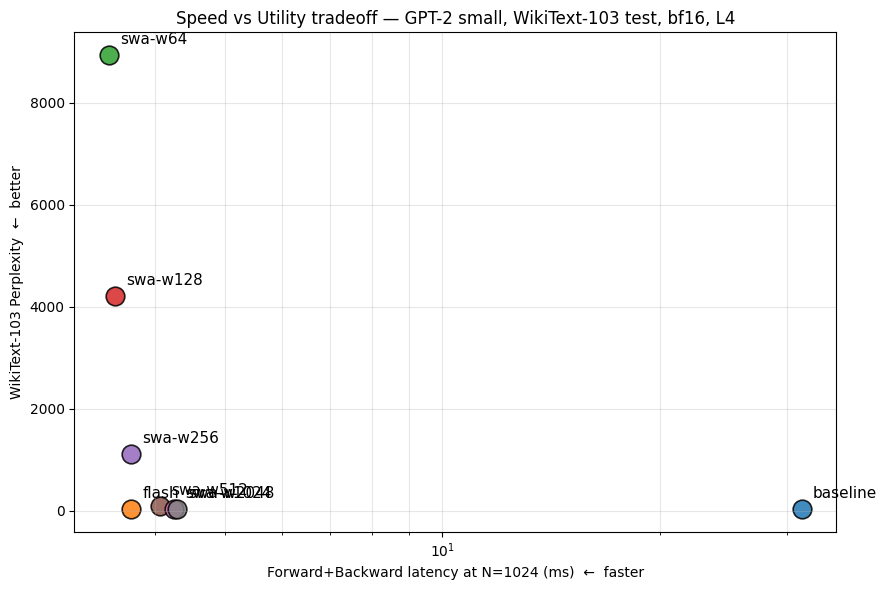

saved → pareto_speed_vs_ppl.png

        Mode      PPL   fwd+bwd (ms)    speedup
--------------------------------------------------
    baseline    30.26         31.398      1.00x
       flash    30.23          3.713      8.46x
     swa-w64  8936.74          3.460      9.07x
    swa-w128  4216.19          3.531      8.89x
    swa-w256  1116.94          3.712      8.46x
    swa-w512    89.71          4.070      7.71x
   swa-w1024    30.23          4.259      7.37x
   swa-w2048    30.23          4.291      7.32x


In [57]:
# Combine speed + utility → Pareto plot and joint table
import json
import matplotlib.pyplot as plt

with open('bench_results.json') as f:
    speed = json.load(f)
with open('ppl_results.json') as f:
    util = json.load(f)

ref_N = util['eval_seq_len']

# Pareto plot: x = fwd+bwd ms at eval seq_len, y = PPL
fig, ax = plt.subplots(figsize=(9, 6))
plotted = []
for r in util['results']:
    label = r['label']
    speed_rows = speed.get(label)
    fb = None
    if speed_rows is not None:
        fb_map = {row['N']: row['fwd_bwd_ms'] for row in speed_rows}
        fb = fb_map.get(ref_N)
        if fb is not None and fb != fb:  # NaN
            fb = None
    if fb is None:
        print(f'[skip plot] no speed data for {label} at N={ref_N}')
        continue
    ax.scatter(fb, r['ppl'], s=180, alpha=0.85, edgecolors='k', linewidths=1.2)
    ax.annotate(label, (fb, r['ppl']), textcoords='offset points', xytext=(8, 8), fontsize=11)
    plotted.append((label, fb, r['ppl']))

ax.set_xlabel(f'Forward+Backward latency at N={ref_N} (ms)  ←  faster')
ax.set_ylabel('WikiText-103 Perplexity  ←  better')
ax.set_xscale('log')
ax.set_title(f'Speed vs Utility tradeoff — GPT-2 small, WikiText-103 test, bf16, L4')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('pareto_speed_vs_ppl.png', dpi=140)
plt.show()
print('saved → pareto_speed_vs_ppl.png')
print()

# Joint table
print(f'{"Mode":>12s}  {"PPL":>7s}  {"fwd+bwd (ms)":>13s}  {"speedup":>9s}')
print('-' * 50)
base_fb = None
for label, fb, ppl in plotted:
    if label == 'baseline':
        base_fb = fb
        break
for r in util['results']:
    label = r['label']
    fb_map = {row['N']: row['fwd_bwd_ms'] for row in speed.get(label, [])}
    fb = fb_map.get(ref_N)
    if fb is None or fb != fb:
        print(f'{label:>12s}  {r["ppl"]:7.2f}  {"N/A":>13s}  {"N/A":>9s}')
    else:
        sp = (base_fb / fb) if base_fb else float('nan')
        print(f'{label:>12s}  {r["ppl"]:7.2f}  {fb:13.3f}  {sp:8.2f}x')


## 8. What to put in the report

From the artifacts saved by this notebook:

- `bench_attention.png` — three-panel figure (fwd / fwd+bwd / peak memory). Use the **fwd+bwd** panel as the main speed figure.
- The speedup table from cell 6 — drop straight into the report.
- The profiler tables from cell 7 — screenshot the `baseline` vs `flash` tables side by side. `baseline` will show 4–6 separate CUDA kernels; `flash` will collapse into one `flash_attention_forward` / `efficient_attention_forward` entry.
- For the **utility** axis (perplexity / accuracy), train each `attn_impl` on WikiText-103 / Hyperpartisan / your sonnet dataset using the existing training scripts — switch by adding `attn_impl=...` to the `GPT2Config(...)` constructor in the relevant model file.

**Expected qualitative results on L4 bf16:**
- `flash` vs `baseline`: ~1.5× speedup at N=512, ~3× at N=2048, baseline OOMs at N=4096 while flash still runs.
- `swa` (with `flash-attn` installed): speedup grows with N/window ratio. At N=4096, w=128, expect ~5–8× over baseline. Without `flash-attn`, `swa` will be ~equal to baseline in speed but lower utility — useful for showing the math-only tradeoff.
- Profiler: `baseline` shows `aten::softmax` + multiple `aten::matmul` lines; `flash` consolidates into one fused kernel.